In [2]:
import numpy as np
import matplotlib.pyplot as plt

def generate_multiple_langevin(n_traj, n_steps, dt, D):

    
    x = np.zeros((n_traj, n_steps))

    scale_factor = np.sqrt(2 * D * dt)

    random_kicks = np.random.normal(0.0, 1.0, size=(n_traj, n_steps))

    
    for traj in range(n_traj):
        for i in range(1, n_steps):
            dx = scale_factor * random_kicks[traj, i-1]
            x[traj, i] = x[traj, i-1] + dx

    return x





n_traj = 5000    
n_steps = 1000  
dt = 0.0001
D = 0.5



trajectories = generate_multiple_langevin(n_traj, n_steps, dt, D)

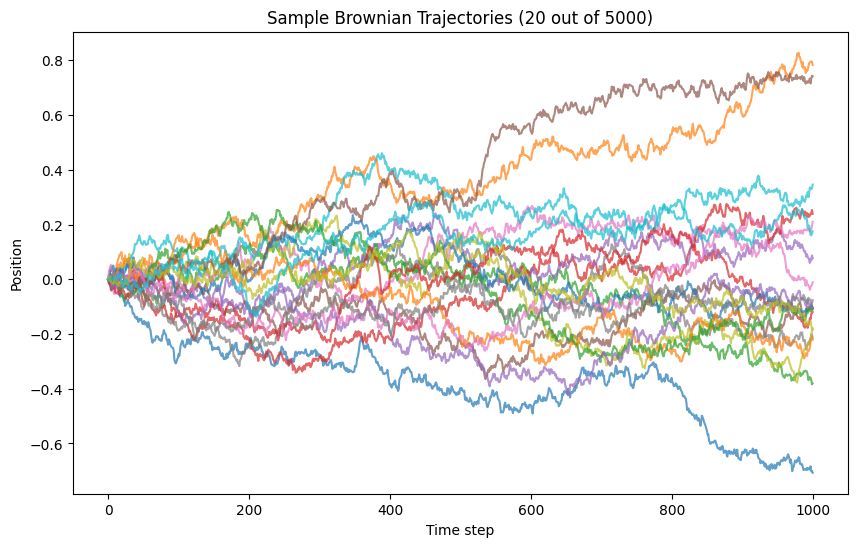

In [4]:
plt.figure(figsize=(10,6))

for traj in range(20):
    plt.plot(trajectories[traj], alpha=0.7)

plt.title("Sample Brownian Trajectories (20 out of 5000)")
plt.xlabel("Time step")
plt.ylabel("Position")
plt.show()

In [5]:
def calculate_tamsd(trajectories, dt):

    n_traj = len(trajectories)

    N = len(trajectories[0])

    max_lag = N - 1

    lags = []
    tamsd_all = []

    for n in range(1, max_lag + 1):
        lags.append(n * dt)

    for traj in range(n_traj):

        trajectory = trajectories[traj]

        tamsd = []

        for n in range(1, max_lag + 1):

            sum_sq = 0
            count = 0

            for i in range(0, N - n):

                dx = trajectory[i + n] - trajectory[i]

                sum_sq = sum_sq + dx * dx
                count = count + 1

            mean_value = sum_sq / count

            tamsd.append(mean_value)

        tamsd_all.append(tamsd)

    tamsd_all = np.array(tamsd_all)

    tamsd_mean = np.mean(tamsd_all, axis=0)

    return np.array(lags), tamsd_all, tamsd_mean


In [6]:
lags, tamsd_all, tamsd_mean = calculate_tamsd(trajectories, dt)

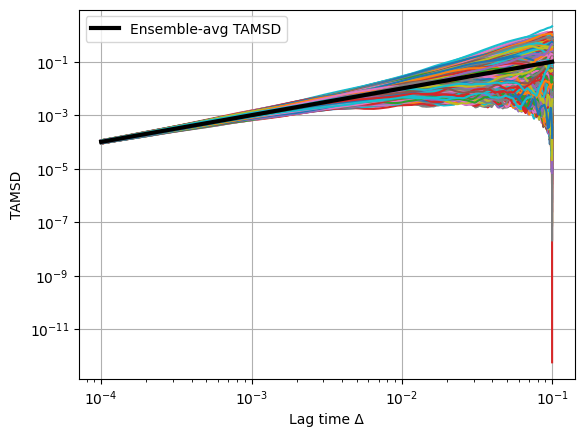

In [7]:
plt.subplot(1,1,1)

for traj in range(n_traj):
    plt.loglog(lags, tamsd_all[traj])

plt.loglog(lags, tamsd_mean, 'k', linewidth=3, label="Ensemble-avg TAMSD")

plt.xlabel("Lag time Δ")
plt.ylabel("TAMSD")

plt.legend()
plt.grid(True)

In [8]:
def calculate_eamsd(trajectories):

    eamsd = np.mean((trajectories - trajectories[:,0][:,None])**2, axis=0)

    return eamsd

In [9]:
eamsd = calculate_eamsd(trajectories)


In [10]:
time = np.arange(n_steps) * dt

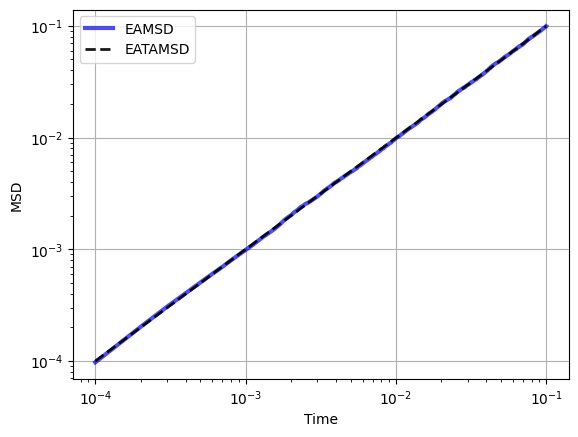

In [11]:
plt.subplot(1,1,1)


plt.loglog(time[1:], eamsd[1:], 'b', linewidth=3, alpha=0.7, label="EAMSD")
plt.loglog(lags, tamsd_mean, 'k--', linewidth=2, alpha=0.9, label="EATAMSD")

plt.xlabel("Time")
plt.ylabel("MSD")

plt.legend()
plt.grid(True)

plt.show()

In [13]:
x = np.log10(lags)
y = np.log10(tamsd_mean)


m, c = np.polyfit(x, y, 1)

print("Slope (alpha):", m)
print("Intercept (c):", c)

Slope (alpha): 0.9986250594726053
Intercept (c): -0.007023150886047338


In [14]:
C = 10**c
D_est = C / 2

print("Estimated D:", D_est)

Estimated D: 0.4919793262961248


In [15]:
def calculate_pairwise_msd(trajectories, dt):

    n_traj = len(trajectories)
    N = len(trajectories[0])

    time_vals = []
    msd_vals = []

    # loop over time i
    for i in range(1, N):

        sum_all_traj = 0

        # loop over trajectories
        for traj in range(n_traj):

            x = trajectories[traj]

            sum_sq = 0

            # loop over all past times j < i
            for j in range(0, i):

                dx = x[i] - x[j]
                sum_sq += dx * dx

            # average over j
            mean_traj = sum_sq / i

            sum_all_traj += mean_traj

        # average over trajectories
        msd_i = sum_all_traj / n_traj

        msd_vals.append(msd_i)
        time_vals.append(i * dt)

    return np.array(time_vals), np.array(msd_vals)

In [16]:
time_pw, msd_pw = calculate_pairwise_msd(trajectories, dt)

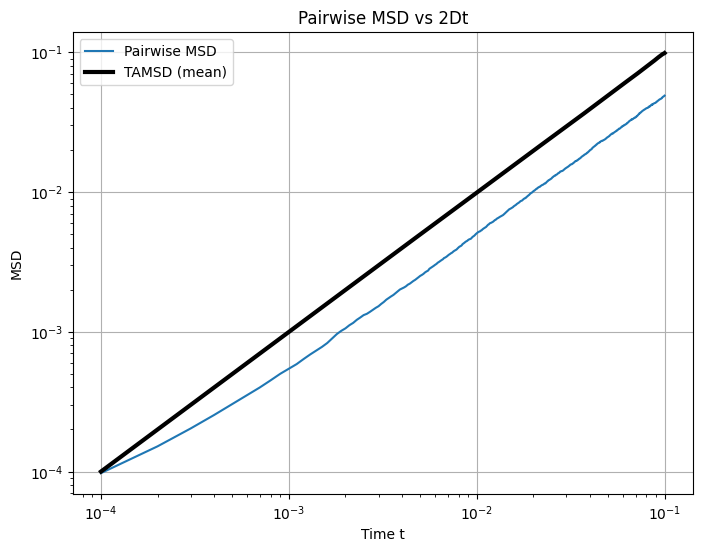

In [17]:
plt.figure(figsize=(8,6))

plt.plot(time_pw, msd_pw, label='Pairwise MSD')

# theory
##plt.plot(time_pw, 2 * D * time_pw, '--', label='2Dt')

plt.loglog(lags, tamsd_mean, 'k', linewidth=3, label="TAMSD (mean)")

plt.xlabel("Time t")
plt.ylabel("MSD")
plt.title("Pairwise MSD vs 2Dt")
plt.legend()
plt.grid(True)



plt.show()

In [18]:
def calculate_eb(tamsd_all):
    
    
    mean_tamsd = np.mean(tamsd_all, axis=0)
    
    
    mean_sq_tamsd = np.mean(tamsd_all**2, axis=0)
    
    
    EB = (mean_sq_tamsd / (mean_tamsd**2)) - 1
    
    return EB

In [19]:
EB = calculate_eb(tamsd_all)

In [20]:
T = time[-1]

EB_theory = (4/3) * (lags / T)

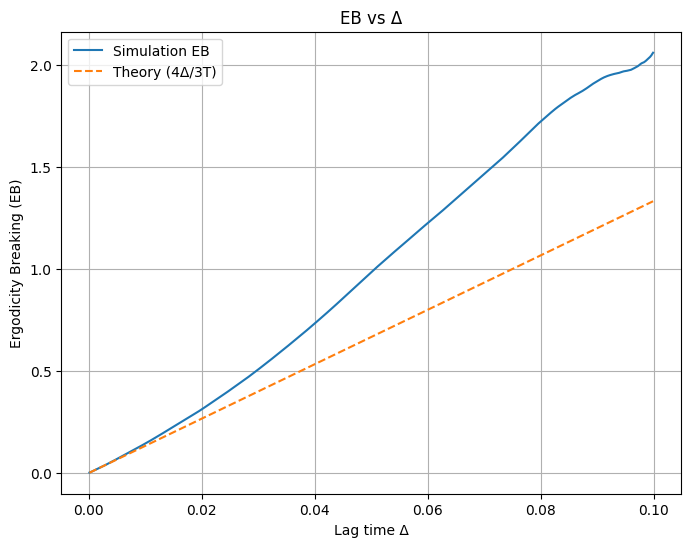

In [21]:
plt.figure(figsize=(8,6))

# Simulation
plt.plot(lags, EB, label='Simulation EB')

# Theory
plt.plot(lags, EB_theory, '--', label='Theory (4Δ/3T)')

plt.xlabel("Lag time Δ")
plt.ylabel("Ergodicity Breaking (EB)")
plt.title("EB vs Δ")
plt.legend()
plt.grid(True)

plt.show()

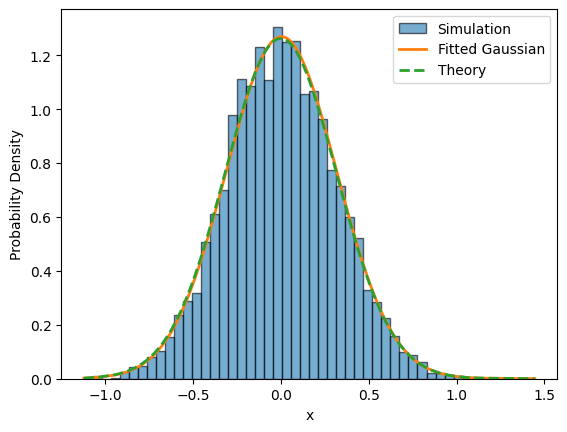

Mean: 0.004259958631319836
Variance: 0.09879375854456092
Expected (2Dt): 0.0999


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm



t_value = time[-1]

positions = trajectories[:, -1]


plt.hist(positions, bins=50, density=True, alpha=0.6, edgecolor='black', label='Simulation')


mu, sigma = norm.fit(positions)

##x_vals = np.linspace(min(positions), max(positions), 500)

x_vals = np.sort(positions)
pdf = norm.pdf(x_vals, mu, sigma)


theory_pdf = (1 / np.sqrt(4 * np.pi * D * t_value)) * \
             np.exp(-(x_vals**2) / (4 * D * t_value))

plt.plot(x_vals, pdf, linewidth=2, label='Fitted Gaussian')
plt.plot(x_vals, theory_pdf, linewidth=2, linestyle='--', label='Theory')

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


print("Mean:", mu)
print("Variance:", sigma**2)
print("Expected (2Dt):", 2 * D * t_value)

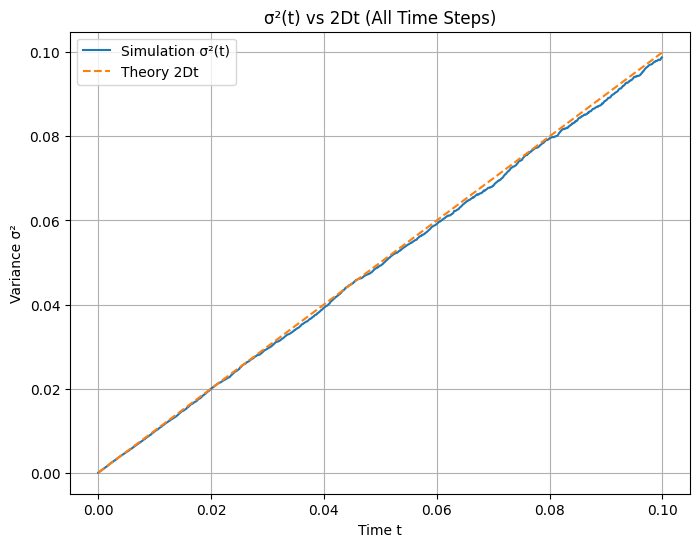

In [23]:


sigma_sq = []


for idx in range(len(time)):

    positions_t = trajectories[:, idx]

   
    var = np.var(positions_t)

    sigma_sq.append(var)

sigma_sq = np.array(sigma_sq)


theory = 2 * D * time




plt.figure(figsize=(8,6))

plt.plot(time, sigma_sq, label='Simulation σ²(t)')
plt.plot(time, theory, '--', label='Theory 2Dt')

plt.xlabel('Time t')
plt.ylabel('Variance σ²')
plt.title('σ²(t) vs 2Dt (All Time Steps)')
plt.legend()
plt.grid(True)

plt.show()

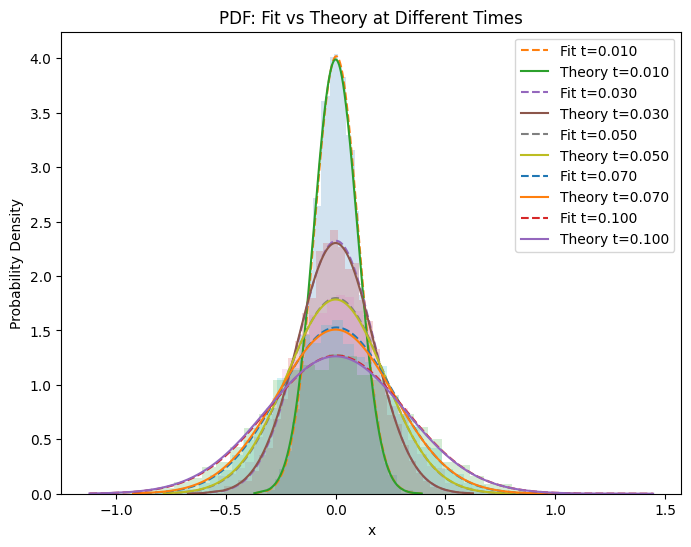

In [24]:

time_indices = [100, 300, 500, 700, 999]

plt.figure(figsize=(8,6))

for idx in time_indices:

    t_val = time[idx]
    positions = trajectories[:, idx]
    plt.hist(positions, bins=40, density=True, alpha=0.2)
    x_vals = np.sort(positions)

    ##x_vals = np.linspace(min(positions), max(positions), 500)

    

    
    mu, sigma = norm.fit(positions)
    pdf_fit = norm.pdf(x_vals, mu, sigma)

    theory_pdf = (1 / np.sqrt(4 * np.pi * D * t_val)) * \
                 np.exp(-(x_vals**2) / (4 * D * t_val))

   
    plt.plot(x_vals, pdf_fit, linestyle='--', label=f'Fit t={t_val:.3f}')
    plt.plot(x_vals, theory_pdf, label=f'Theory t={t_val:.3f}')
   


plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('PDF: Fit vs Theory at Different Times')
plt.legend()
plt.show()



In [25]:


lag = 2

N = trajectories.shape[1]
n_traj = trajectories.shape[0]

msd_step2 = []


for i in range(0, N - lag):

  
    dx = trajectories[:, i + lag] - trajectories[:, i]

    
    msd_val = np.mean(dx**2)

    msd_step2.append(msd_val)

msd_step2 = np.array(msd_step2)


time_step2 = np.arange(len(msd_step2)) * dt

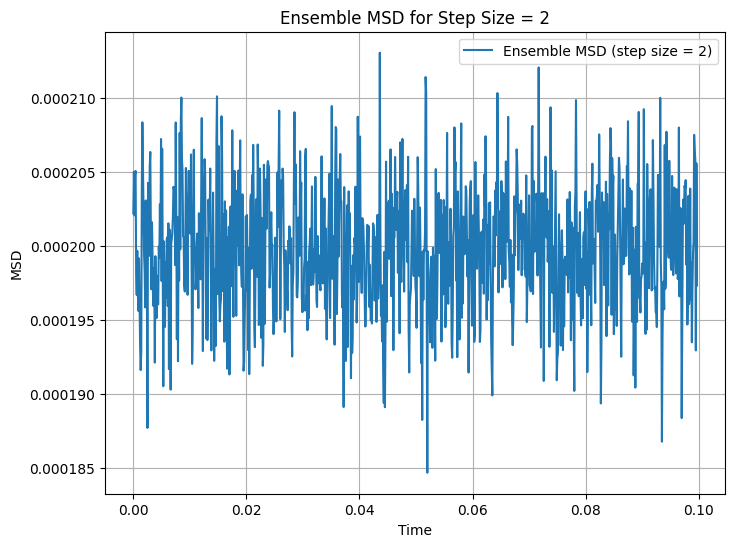

In [26]:
plt.figure(figsize=(8,6))

plt.plot(time_step2, msd_step2, label="Ensemble MSD (step size = 2)")

# theory: MSD = 2D * (lag * dt)
theory_val = 2 * D * (lag * dt)

#plt.axhline(theory_val, linestyle='--', label="Theory (2D·2dt)")

plt.xlabel("Time")
plt.ylabel("MSD")
plt.title("Ensemble MSD for Step Size = 2")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
lags_list = [2, 10, 15, 20, 50, 60, 70, 100]

msd_dict = {}

for lag in lags_list:

    msd = []

    for i in range(0, trajectories.shape[1] - lag):

        dx = trajectories[:, i + lag] - trajectories[:, i]
        msd_val = np.mean(dx**2)

        msd.append(msd_val)

    msd = np.array(msd)

    time_axis = np.arange(len(msd)) * dt

    msd_dict[lag] = (time_axis, msd)

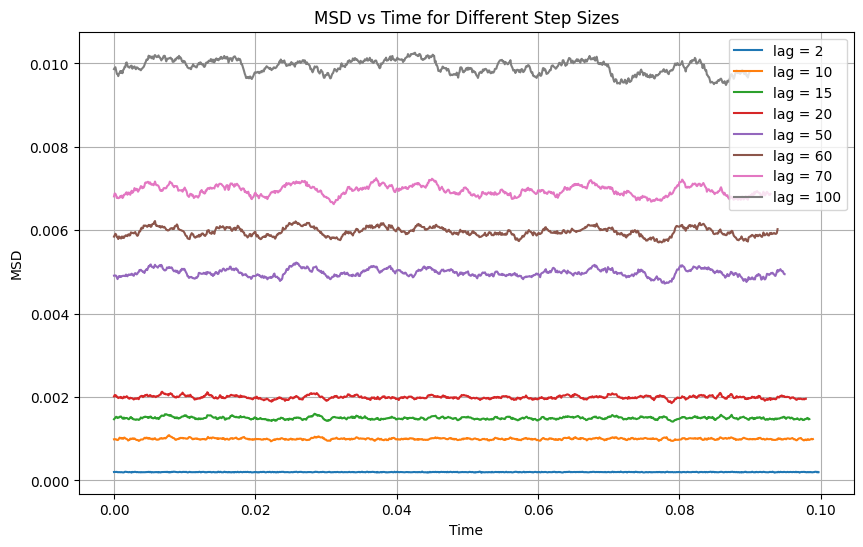

In [40]:
plt.figure(figsize=(10,6))

for lag in lags_list:
    time_axis, msd = msd_dict[lag]
    plt.plot(time_axis, msd, label=f'lag = {lag}')

plt.xlabel("Time")
plt.ylabel("MSD")
plt.title("MSD vs Time for Different Step Sizes")
plt.legend()
plt.grid(True)

plt.show()

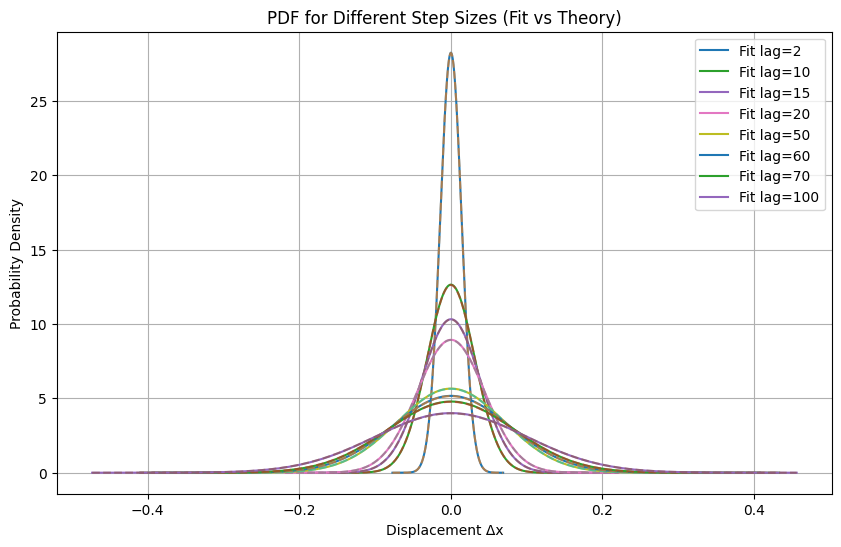

In [41]:
from scipy.stats import norm

lags_list = [2, 10, 15, 20, 50, 60, 70, 100]

plt.figure(figsize=(10,6))

for lag in lags_list:

    dx_all = []

    # collect ALL displacements
    for i in range(0, trajectories.shape[1] - lag):
        dx = trajectories[:, i + lag] - trajectories[:, i]
        dx_all.extend(dx)

    dx_all = np.array(dx_all)

    # -----------------------
    # Fit Gaussian (DATA)
    # -----------------------
    mu, sigma = norm.fit(dx_all)

    x_vals = np.linspace(min(dx_all), max(dx_all), 500)
    pdf_fit = norm.pdf(x_vals, mu, sigma)

    # -----------------------
    # Theory
    # -----------------------
    sigma_theory = np.sqrt(2 * D * (lag * dt))
    pdf_theory = norm.pdf(x_vals, 0, sigma_theory)

    # -----------------------
    # Plot
    # -----------------------
    plt.plot(x_vals, pdf_fit, label=f'Fit lag={lag}')
    plt.plot(x_vals, pdf_theory, '--', alpha=0.6)

plt.xlabel("Displacement Δx")
plt.ylabel("Probability Density")
plt.title("PDF for Different Step Sizes (Fit vs Theory)")
plt.legend()
plt.grid(True)

plt.show()

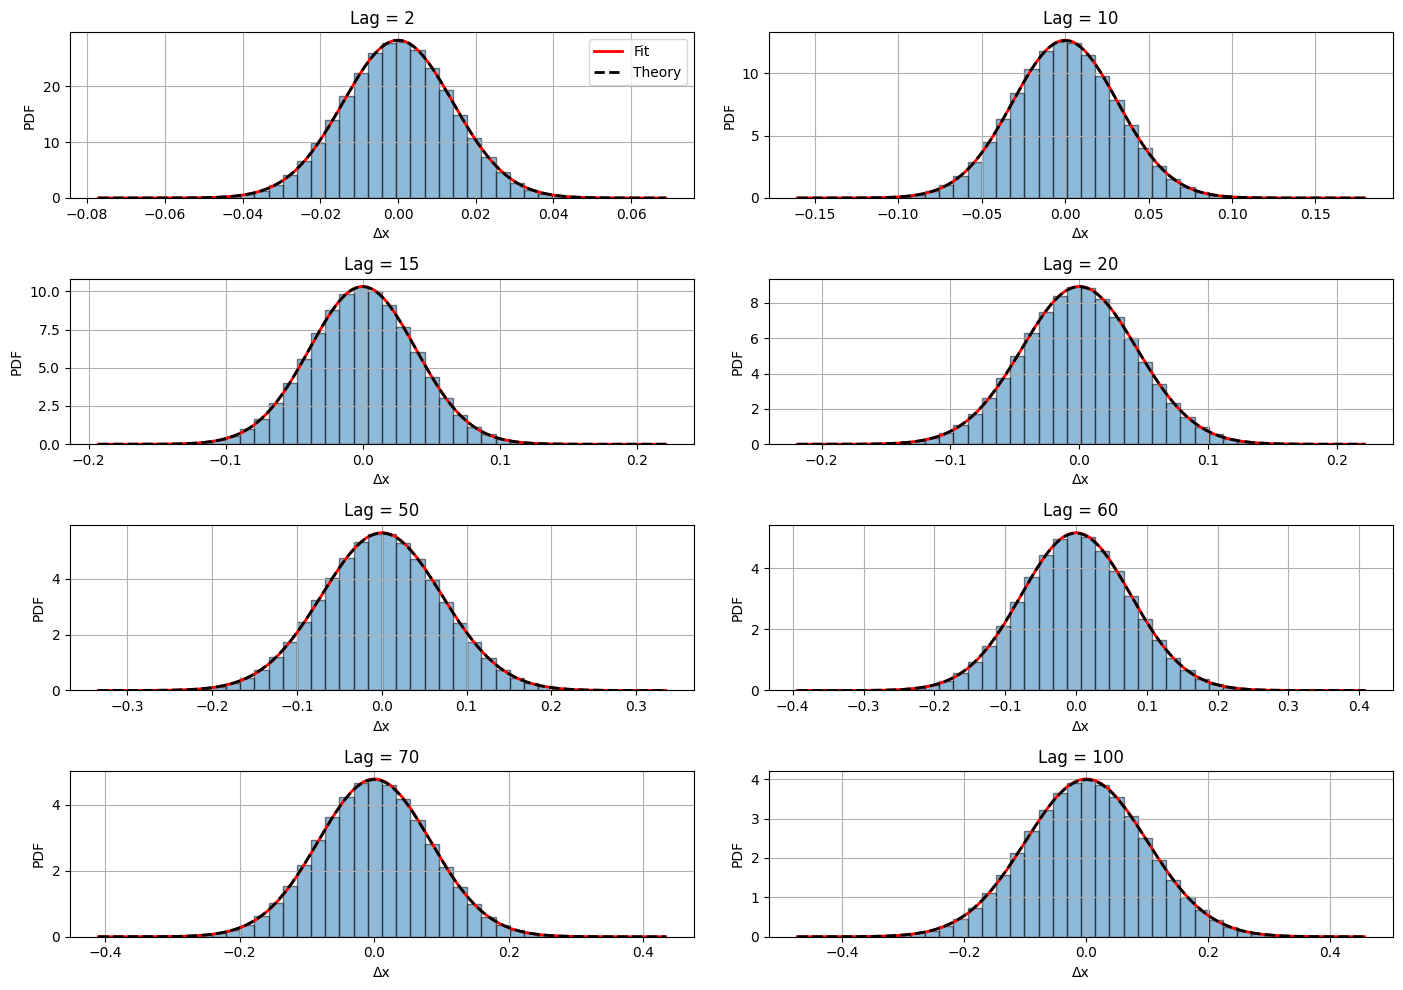

In [48]:
from scipy.stats import norm

lags_list = [2, 10, 15, 20, 50, 60, 70, 100]

plt.figure(figsize=(14,10))

for idx, lag in enumerate(lags_list):

    dx_all = []

    # collect displacements
    for i in range(0, trajectories.shape[1] - lag):
        dx = trajectories[:, i + lag] - trajectories[:, i]
        dx_all.extend(dx)

    dx_all = np.array(dx_all)

    # -----------------------
    # Fit Gaussian (DATA)
    # -----------------------
    mu, sigma = norm.fit(dx_all)

    x_vals = np.linspace(min(dx_all), max(dx_all), 500)
    pdf_fit = norm.pdf(x_vals, mu, sigma)

    # -----------------------
    # Theory
    # -----------------------
    sigma_theory = np.sqrt(2 * D * (lag * dt))
    pdf_theory = norm.pdf(x_vals, 0, sigma_theory)

    # -----------------------
    # Subplot
    # -----------------------
    plt.subplot(4, 2, idx+1)

    # Histogram
    plt.hist(dx_all, bins=40, density=True, alpha=0.5, edgecolor='black')

    # Fit
    plt.plot(x_vals, pdf_fit, 'r', linewidth=2, label='Fit')

    # Theory
    plt.plot(x_vals, pdf_theory, 'k--', linewidth=2, label='Theory')

    plt.title(f'Lag = {lag}')
    plt.xlabel('Δx')
    plt.ylabel('PDF')
    plt.grid(True)

    if idx == 0:
        plt.legend()

plt.tight_layout()
plt.show()

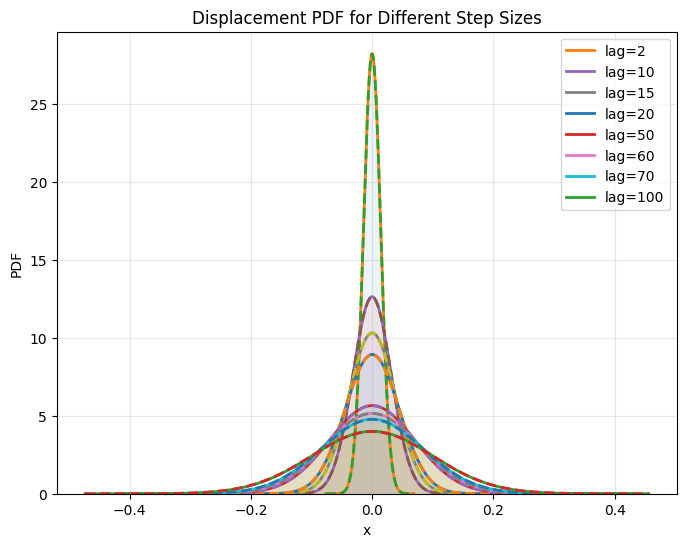

In [47]:
from scipy.stats import norm

lags_list = [2, 10, 15, 20, 50, 60, 70, 100]

plt.figure(figsize=(8,6))

for lag in lags_list:

    dx_all = []

    for i in range(0, trajectories.shape[1] - lag):
        dx = trajectories[:, i + lag] - trajectories[:, i]
        dx_all.extend(dx)

    dx_all = np.array(dx_all)

    # Fit
    mu, sigma = norm.fit(dx_all)

    x_vals = np.linspace(min(dx_all), max(dx_all), 400)

    pdf_fit = norm.pdf(x_vals, mu, sigma)
    pdf_theory = norm.pdf(x_vals, 0, np.sqrt(2 * D * lag * dt))

    # Histogram (light, transparent)
    plt.hist(dx_all, bins=60, density=True, alpha=0.08)

    # Fit (solid line)
    plt.plot(x_vals, pdf_fit, linewidth=2, label=f'lag={lag}')

    # Theory (dashed)
    plt.plot(x_vals, pdf_theory, '--', linewidth=2)

plt.xlabel("x")
plt.ylabel("PDF")
plt.title("Displacement PDF for Different Step Sizes")

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

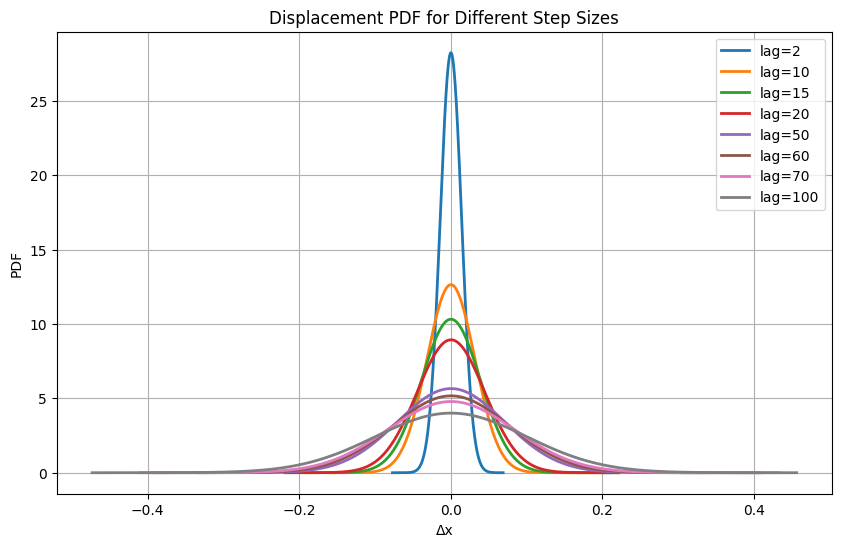

In [49]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

lags_list = [2, 10, 15, 20, 50, 60, 70, 100]

plt.figure(figsize=(10,6))

for lag in lags_list:

    dx_all = []

    # collect displacements
    for i in range(0, trajectories.shape[1] - lag):
        dx = trajectories[:, i + lag] - trajectories[:, i]
        dx_all.extend(dx)

    dx_all = np.array(dx_all)

    # Fit Gaussian
    mu, sigma = norm.fit(dx_all)

    x_vals = np.linspace(min(dx_all), max(dx_all), 500)
    pdf_fit = norm.pdf(x_vals, mu, sigma)

    # Plot ONLY fitted PDF (clean view)
    plt.plot(x_vals, pdf_fit, linewidth=2, label=f'lag={lag}')

# labels
plt.xlabel('Δx')
plt.ylabel('PDF')
plt.title('Displacement PDF for Different Step Sizes')

plt.legend()
plt.grid(True)

plt.show()

In [51]:
from scipy.stats import norm
import numpy as np

def calculate_pdf(trajectories, lags_list, dt, D):

    pdf_data = []

    for lag in lags_list:

        dx_all = []

        for i in range(0, trajectories.shape[1] - lag):
            dx = trajectories[:, i + lag] - trajectories[:, i]
            dx_all.extend(dx)

        dx_all = np.array(dx_all)

        # fit
        mu, sigma = norm.fit(dx_all)

        x_vals = np.linspace(min(dx_all), max(dx_all), 500)
        pdf_fit = norm.pdf(x_vals, mu, sigma)

        # theory
        sigma_theory = np.sqrt(2 * D * (lag * dt))
        pdf_theory = norm.pdf(x_vals, 0, sigma_theory)

        pdf_data.append((lag, x_vals, dx_all, pdf_fit, pdf_theory))

    return pdf_data

In [52]:
lags_list = [2, 10, 15, 20, 50, 60, 70, 100]

pdf_data = calculate_pdf(trajectories, lags_list, dt, D)

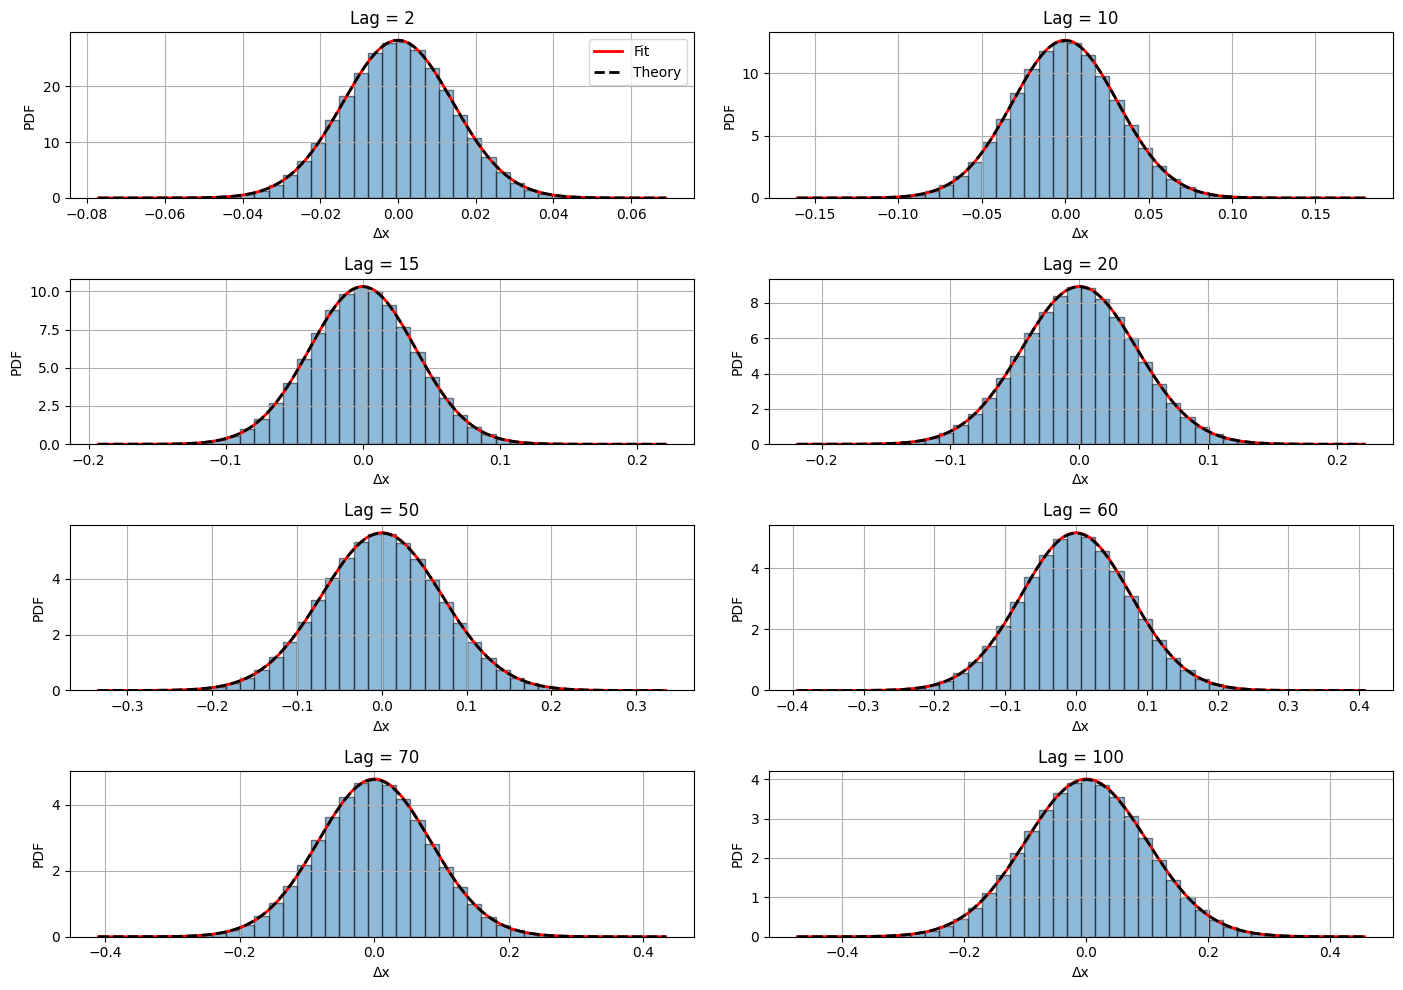

In [53]:
plt.figure(figsize=(14,10))

for idx, (lag, x_vals, dx_all, pdf_fit, pdf_theory) in enumerate(pdf_data):

    plt.subplot(4, 2, idx+1)

    plt.hist(dx_all, bins=40, density=True, alpha=0.5, edgecolor='black')

    plt.plot(x_vals, pdf_fit, 'r', linewidth=2, label='Fit')
    plt.plot(x_vals, pdf_theory, 'k--', linewidth=2, label='Theory')

    plt.title(f'Lag = {lag}')
    plt.xlabel('Δx')
    plt.ylabel('PDF')
    plt.grid(True)

    if idx == 0:
        plt.legend()

plt.tight_layout()
plt.show()

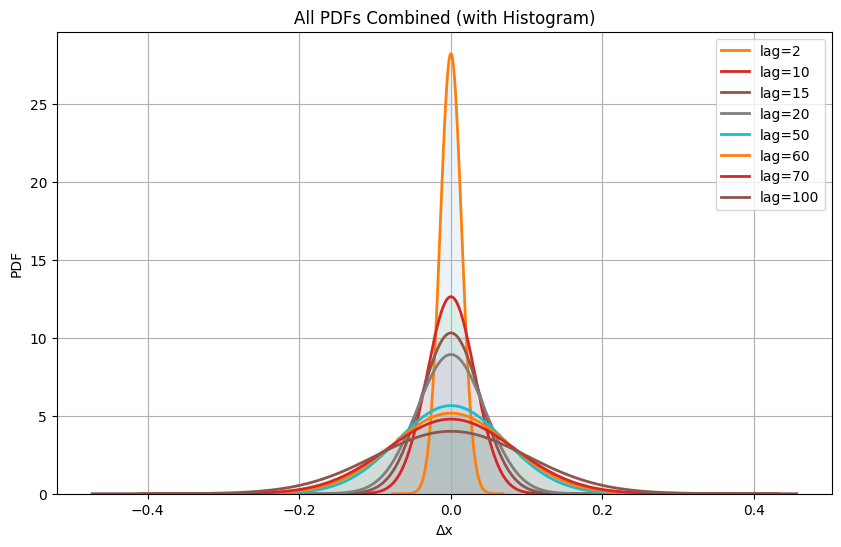

In [ ]:
plt.figure(figsize=(10,6))

for (lag, x_vals, dx_all, pdf_fit, pdf_theory) in pdf_data:

    
    plt.hist(dx_all, bins=40, density=True, alpha=0.08)

   
    plt.plot(x_vals, pdf_fit, linewidth=2, label=f'lag={lag}')

plt.xlabel('Δx')
plt.ylabel('PDF')
plt.title('All PDFs Combined (with Histogram)')

plt.legend()
plt.grid(True)

plt.show()